In [228]:
# install PyTorch

%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [229]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [230]:
torch.set_default_dtype(torch.float32)

# # Define domain - Parameters
x_max, z_max, t_max = 1000.0, 1000.0, 0.5
v     = 2000.0   # m/s, constant (Week 1)
f0    = 5.0      # Hz  ← change this for the frequency sweep: 2,5,10,20,40
x_src = 500.0
z_src = 500.0
#sigma = 100.0    # spatial Gaussian width [m]
t0    = 3.0/(torch.pi*f0)  # Ricker peak delay [s] The Ricker is effectively zero at 3 half-periods from the peak

# # Ricker wavelet (spatial, at t=0) ────────────────────────
# def ricker_wavelet(t, f0, t0):
#     r =  torch.pi * f0 * (t - t0)
#     return (1 - 2*r**2) * torch.exp(-r**2)

def ricker_wavelet(x, z, f0=5.0, x_src=500.0, z_src=500.0, v=2000.0):
    sigma = v / (2 * torch.pi * f0)          # sigma scales with frequency
    r2 = (x - x_src)**2 + (z - z_src)**2
    xi = r2 / (2 * sigma**2)
    return (1 - 2*xi) * torch.exp(-xi)       # Mexican hat / Ricker shape

def ricker_time(t, f0, t0):
    """Ricker wavelet in time — controls frequency content."""
    pt = torch.pi * f0 * (t - t0)
    pt2 = pt**2
    return (1 - 2*pt2) * torch.exp(-pt2)

def gaussian_space(x, z, x_src, z_src, sigma):
    """Spatial Gaussian — localizes source position."""
    r2 = (x - x_src)**2 + (z - z_src)**2
    return torch.exp(-r2 / (2 * sigma**2))

def source(x, z, t, f0, t0, x_src = 500.0, z_src = 500.0, sigma = 100.0, A=1.0):
    """Full source term: s(t) * g(x,z)"""
    ricker = ricker_time(t, f0, t0)
    spatial = gaussian_space(x, z, x_src, z_src, sigma)
    return ricker*spatial*A


# Collocation points (random, inside domain)
n1 = 5000
xn = torch.rand(n1, 1, dtype=torch.float32) * x_max
zn = torch.rand(n1, 1, dtype=torch.float32) * z_max
tn = torch.rand(n1, 1, dtype=torch.float32) * t_max

# Initial condition points (t=0, random x and z)
n = 1000
x_ic = torch.rand(n, 1, dtype=torch.float32) * x_max
z_ic = torch.rand(n, 1, dtype=torch.float32) * z_max
# u(x,z,0) = spatial Gaussian * Ricker evaluated at t=0
u_ic = source(x_ic, z_ic, torch.zeros(n, 1), f0, t0, x_src, z_src, sigma)
u_ic = -u_ic / u_ic.abs().max() 

# Boundary condition points (edges of domain, random t)
N_bc = 1000
t_bc = torch.rand(N_bc, 1, dtype=torch.float32) * t_max
x_bc = torch.cat([
    torch.zeros(N_bc//4, 1),          # left edge   x=0
    torch.full((N_bc//4, 1), x_max),  # right edge  x=x_max
    torch.rand(N_bc//4, 1) * x_max,   # top edge    z=0
    torch.rand(N_bc//4, 1) * x_max,   # bottom edge z=z_max
], dim=0)
z_bc = torch.cat([
    torch.rand(N_bc//4, 1) * z_max,
    torch.rand(N_bc//4, 1) * z_max,
    torch.zeros(N_bc//4, 1),
    torch.full((N_bc//4, 1), z_max),
], dim=0)

In [231]:

#fourier
class PINN(nn.Module):

    def __init__(self, num_fourier=32):
        super().__init__()
        torch.manual_seed(42)           # reproducible init
        B = torch.randn(3, num_fourier) * 2.0   # smaller scale, was 10.0 or 1.0
        self.register_buffer('B', B)
    
        self.net = nn.Sequential(
            nn.Linear(num_fourier*2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
    )




# Making the neutral network to represent the wavefield u(x,z,t)/ function approx 

# class PINN(nn.Module):
#     def __init__(self, layers = [3, 64,64,64,1]):
#         super().__init__()
        

#         self.net = nn.Sequential(
#             nn.Linear(3,64), nn.Tanh(),   #The chain from input to output
#             nn.Linear(64,64), nn.Tanh(),  # nn.Linear does one matric multiplixation
#             nn.Linear(64,64), nn.Tanh(),  # no nn.Tanh() -> the wavefield can any real number,
#             nn.Linear(64,1)              # Do not want to squish the output between -1 and 1.
#             )


        
# Input layer:   3 neurons  ← (x, z, t)
# Hidden layer:  64 neurons
# Hidden layer:  64 neurons  
# Hidden layer:  64 neurons
# Output layer:  1 neuron   ← û(x,z,t)

# super().__init__()
# self.net

# nn.Linear():  It takes the values from the previous layer and combines them into the next layer.
# nn.Tanh():    Sfter each one squishes the result into a nonlinear shape


# (x, z, t)          3 numbers in

# nn.Linear(3, 64)   multiply by a 3×64 matrix → 64 numbers
# nn.Tanh()          squish each through tanh

# nn.Linear(64, 64)  multiply by 64×64 matrix → 64 numbers
# nn.Tanh()          squish again

# nn.Linear(64, 64)  multiply by 64×64 matrix → 64 numbers
# nn.Tanh()          squish again

# nn.Linear(64, 1)   multiply by 64×1 matrix → 1 number

# û(x, z, t)         one wavefield value out

# The matrices (weights) are what gets learned during training, 
# they start random and gradually adjust so the output satisfies
# your loss function.


    # def forward(self, x, z, t):
    #     x= (x - 500) / 500      # normalize to [-1, 1]
    #     z= (z - 500) / 500
    #     t= (t - 0.25) / 0.25
    #     t = t/0.5
    #     inputs= torch.cat([x,z,t], dim = 1)
    
    #     return self.net(inputs)
    
        #inputs= torch.cat([x,z,t], dim = 1)
        #return self.net(inputs)

# Input: (x,z,t) a point in space and time.
# Output: Û a predicted wavefield value at that point.


# fourierk 
    def forward(self, x, z, t):
        xn = x / 1000.0
        zn = z / 1000.0
        tn = t / 0.5
        coords = torch.cat([xn, zn, tn], dim=1)   # (N, 3)
        proj = coords @ self.B                      # (N, 16)
        features = torch.cat([torch.sin(proj), torch.cos(proj)], dim=1)  # (N, 32)
        return self.net(features)

In [232]:
# The Partiell Diff. Equation PDE residual computation via autograd
# NO finite differences (FD)


def pde_rest(model, x, z, t, v,f0, t0):
    x.requires_grad_(True)
    z.requires_grad_(True)
    t.requires_grad_(True)

    u = model(x,z,t)

    u_t  = torch.autograd.grad(u, t,  grad_outputs=torch.ones_like(u), create_graph=True)[0]     # ∂û/∂t
    u_tt = torch.autograd.grad(u_t, t, grad_outputs=torch.ones_like(u_t), create_graph=True)[0]  # ∂²û/∂t²
    u_xx = torch.autograd.grad(
               torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0], # ∂²û/∂x²
               x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_zz = torch.autograd.grad(
               torch.autograd.grad(u, z, grad_outputs=torch.ones_like(u), create_graph=True)[0], # ∂²û/∂z²
               z, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    
    src = source(xn, zn, tn, f0, t0)  
 
    
    residual = u_tt - v**2 * (u_xx + u_zz)-src  # ∂²û/∂t² - v²(x,z) * (∂²û/∂x²+ ∂²û/∂z²)
    return residual



    

# PDE res is how much the network's prediction violates the wave equation (WEq). 
# If the netwrok perfectly solved the WEq, is is equal to zero. 
# thus the residual will not be zero, big res = network is violating physics badly there
# The loss function will later force r to move twoards Zero during traing 

# NO GRID NEEDED
# A batch of (x,z,t) points — called collocation points are scattered randomly across the domain.
# For example 10,000 random points inside (x,z,t) cube.
# The network predicts û at each point, and then 
# check whether r(x,z,t) = WEq  is satisfied at each one.

# What does requires_grad_(True) do?
# It holds on to the derivatives with respect to this variable,
# tracking every operation involving it (for later use)
# it records the derivation chain

# Instead of x+i and needing to update: 
# PyTorch builds a computation graph as the forward pass runs.
# Every operation involving x gets recorded in a chain:
# x → Linear → Tanh → Linear → Tanh → ... → û
# When you call autograd.grad, it walks backwards through that
# chain applying the chain rule automatically — giving you ∂û/∂x
# at every point simultaneously


In [233]:
# The loss fuction

def loss_func(model, xn, zn, tn, v, f0, t0,     # collocation points
                    x_ic, z_ic, u_ic,           # initial condtition points
                    x_bc, z_bc, t_bc            # bouondary condition point
                    ):  
    
    # PDE loss
    res = pde_rest(model, xn, zn, tn, v, f0, t0)
    L_pde = torch.mean(res**2)                      # square mean of 

    # Initial condition loss (u=0, u_t=source wavelet at t=0)
    u_pred_ic = model(x_ic, z_ic, torch.zeros_like(x_ic))
    L_ic = torch.mean((u_pred_ic - u_ic)**2)        # least-square mean 


    # Boundary condition loss (u=0 at edges)
    u_pred_bc = model(x_bc, z_bc, t_bc)
    L_bc = torch.mean(u_pred_bc**2)                 # square mean of 
 
    #print(f"  L_pde={L_pde.item():.4f}, L_ic={L_ic.item():.4f}, L_bc={L_bc.item():.4f}")
    return L_pde + 100*L_ic + L_bc

# model_test = PINN()
# optimizer_test = torch.optim.Adam(model_test.parameters(), lr=1e-3)
# optimizer_test.zero_grad()
# loss = loss_func(model_test, xn, zn, tn, v, x_ic, z_ic, u_ic, x_bc, z_bc, t_bc)


# L_PDE
# It takes the mean of the squared residual across all collocation points.
# As a time-stepping sense across all the random (x,z,t) points scattered 
# through the domain simultaneously. 
# Mean squared because negative and positive residuals would otherwise cancel.

#L_ic
# Least mean squares comparing predicted û
# against the known initial condition u_ic at t=0.
# The initial condition is the source wavelet-> a Ricker pulse at the source location,
# zero everywhere else. This is telling the network: "at t=0
# your output must match this wavelet shape."

#L_bc
# enforcing that û = 0 at the edges, 
# so there is no u_bc target term
# It is an absorbing boundary condition:
# it stops the wave reflecting off the edges of the domain back inward.

# The Total loss: 
# L_PDE + L_ic + L_bc
print(f"n_pde={n}, t_max={t_max}, v={v}, f0={f0}, t0={t0}")

n_pde=1000, t_max=0.5, v=2000.0, f0=5.0, t0=0.19098593171027442


Epoch 0, Loss: 15.872231
Epoch 500, Loss: 2.065114
Epoch 1000, Loss: 1.713763
Epoch 1500, Loss: 1.473230
Epoch 2000, Loss: 1.107147
Epoch 2500, Loss: 0.831911
Epoch 3000, Loss: 0.679317
Epoch 3500, Loss: 0.569504
Epoch 4000, Loss: 0.495252
Epoch 4500, Loss: 0.435063
Epoch 5000, Loss: 0.391860
Epoch 5500, Loss: 0.346987
Epoch 6000, Loss: 0.308729
Epoch 6500, Loss: 0.274587
Epoch 7000, Loss: 0.250900
Epoch 7500, Loss: 0.231119
Epoch 8000, Loss: 0.211061
Epoch 8500, Loss: 0.193749
Epoch 9000, Loss: 0.181390
Epoch 9500, Loss: 0.170380
Epoch 10000, Loss: 0.160255
Epoch 10500, Loss: 0.151522
Epoch 11000, Loss: 0.144877
Epoch 11500, Loss: 0.133568
Epoch 12000, Loss: 0.130824
Epoch 12500, Loss: 0.125855
Epoch 13000, Loss: 0.117171
Epoch 13500, Loss: 0.112478
Epoch 14000, Loss: 0.112903
Epoch 14500, Loss: 0.108136
Epoch 15000, Loss: 0.100052
Epoch 15500, Loss: 0.096653
Epoch 16000, Loss: 0.094631
Epoch 16500, Loss: 0.088697
Epoch 17000, Loss: 0.088345
Epoch 17500, Loss: 0.083730
Epoch 18000, Lo

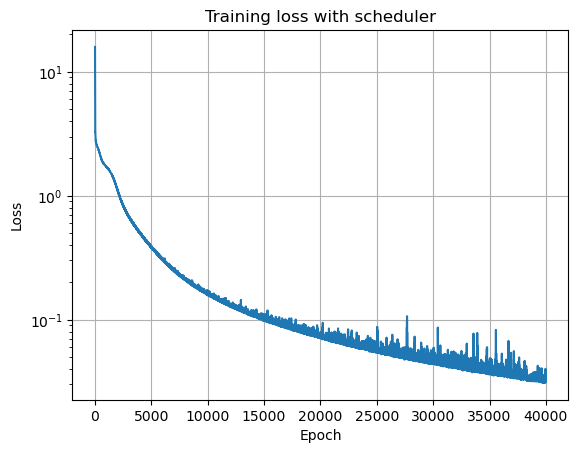

In [234]:
# Traning loop => optimizer 

model = PINN()
losses=[]
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                                        patience=500, 
                                                        factor=0.8)             #factor=0.5 → cleaner wavefield but bigger spikes in loss
                                                                                #factor=0.8 → smoother loss curve but noisier wavefield
    

for tiff in range(40000):   

 
    optimizer.zero_grad()
    xn = torch.rand(n1, 1) * x_max;  xn.requires_grad_(True) # sjekkk ut dettte,hvorofr er det her? hva gjorde at jeg fikk bedre svar bed å gjøre dette. hmm
    zn = torch.rand(n1, 1) * z_max;  zn.requires_grad_(True)
    tn = torch.rand(n1, 1) * t_max;  tn.requires_grad_(True)
    loss = loss_func(model, xn, zn, tn, v, f0, t0,
                            x_ic, z_ic, u_ic,
                            x_bc, z_bc, t_bc
                            )
    loss.backward()
    optimizer.step()
    scheduler.step(loss.detach()) 
    losses.append(loss.item()) 

    if tiff % 500 == 0:
        print(f"Epoch {tiff}, Loss: {loss.item():.6f}")
      

# taking 10000 gradients step/iteration. one iteration is one full pass through the traning loop:
# 1. Takes the current network weights
# 2. Computes the loss
# 3. Computes gradients via backpropagation
# 4. Takes one small step to reduce the loss
# 5. Repeats
# Sep size: 1r=1e-3. before for FD this was the linspace grid nodes.
# taking 10000 gradients step/iteration. The Network weghts are the model, 
# the loss is what is minimizing, alpha is the stepsize 


#FD vs PINNs (Tomography vs PINNs)
# observation = G × model_parameters
# PDE_residual = f(network_weights, x, z, t)

# other optimizers:
# L-BFGS 
# SGD 
# 
# 


plt.semilogy(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss with scheduler")
plt.grid(True)
plt.show()

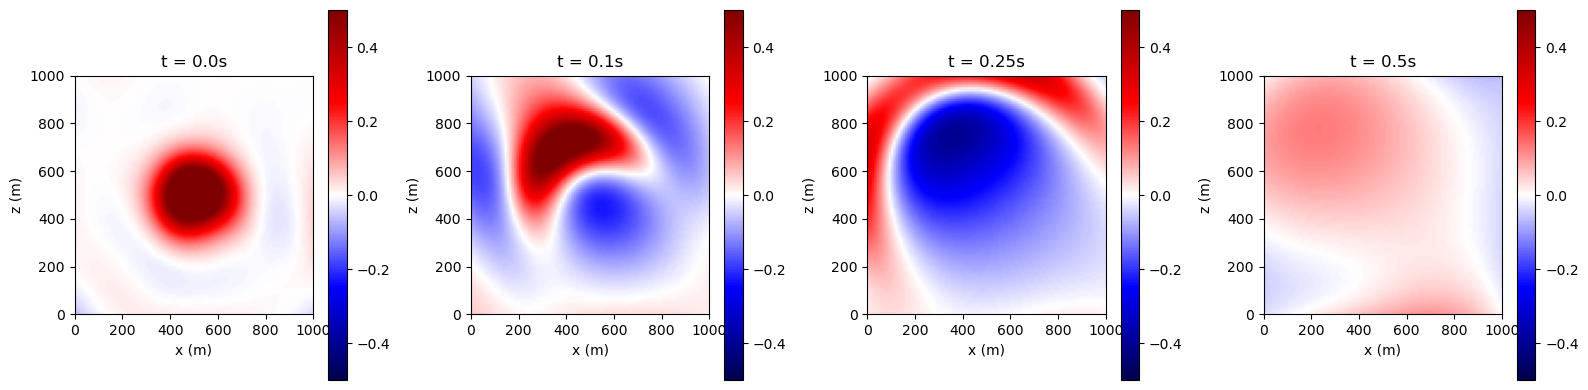

In [235]:
import numpy as np

# Create a grid for visualization
nx, nz = 100, 100
x_plot = torch.linspace(0, 1000, nx, dtype=torch.float32)
z_plot = torch.linspace(0, 1000, nz, dtype=torch.float32)
XX, ZZ = torch.meshgrid(x_plot, z_plot, indexing='ij')
XX_flat = XX.reshape(-1, 1)
ZZ_flat = ZZ.reshape(-1, 1)


fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, t_val in zip(axes, [0.0, 0.1, 0.25, 0.5]):
    TT = torch.full_like(XX_flat, t_val)
    with torch.no_grad():
        u_pred = model(XX_flat, ZZ_flat, TT).reshape(nx, nz)
    
    vmax = float(u_pred.abs().max()) 
    im = ax.imshow(u_pred.numpy().T, origin='lower',
                   extent=[0, 1000, 0, 1000], cmap='seismic',
                   vmin=-0.5, vmax=0.5)
    ax.set_title(f't = {t_val}s')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('z (m)')
    plt.colorbar(im, ax=ax)


plt.tight_layout()
plt.show()

Diagenostikk:

In [236]:
with torch.no_grad():
    u_test = model(XX_flat, ZZ_flat, torch.full_like(XX_flat, 0.1))
print(u_test.min(), u_test.max())

tensor(-0.2293) tensor(0.6545)


In [237]:
with torch.no_grad():
    u_t0 = model(XX_flat, ZZ_flat, torch.zeros_like(XX_flat))
print(u_t0.min(), u_t0.max())

tensor(-0.0582) tensor(0.9729)


In [238]:
u_ic = source(x_ic, z_ic, torch.zeros(n, 1), f0, t0)
u_ic = u_ic / u_ic.abs().max()   # normalize — but also check sign
print(u_ic.min(), u_ic.max()) 

tensor(-1.) tensor(-1.6373e-11)


In [239]:
raw = source(x_ic, z_ic, torch.zeros(n, 1), f0, t0, x_src, z_src, sigma)
print(raw.min(), raw.max())

raw = source(x_ic, z_ic, torch.zeros(n, 1), f0, t0, x_src, z_src, sigma)
u_ic = -raw / raw.abs().max()
print(u_ic.min(), u_ic.max())

tensor(-0.0021) tensor(-3.4121e-14)
tensor(1.6373e-11) tensor(1.)


In [240]:
print(f"domain: x=[0,{x_max}], z=[0,{z_max}]")
print(f"v={v}, f0={f0}, t0={t0:.4f}, t_max={t_max}")
print(f"source at x={x_src}, z={z_src}, sigma={sigma}")

domain: x=[0,1000.0], z=[0,1000.0]
v=2000.0, f0=5.0, t0=0.1910, t_max=0.5
source at x=500.0, z=500.0, sigma=100.0


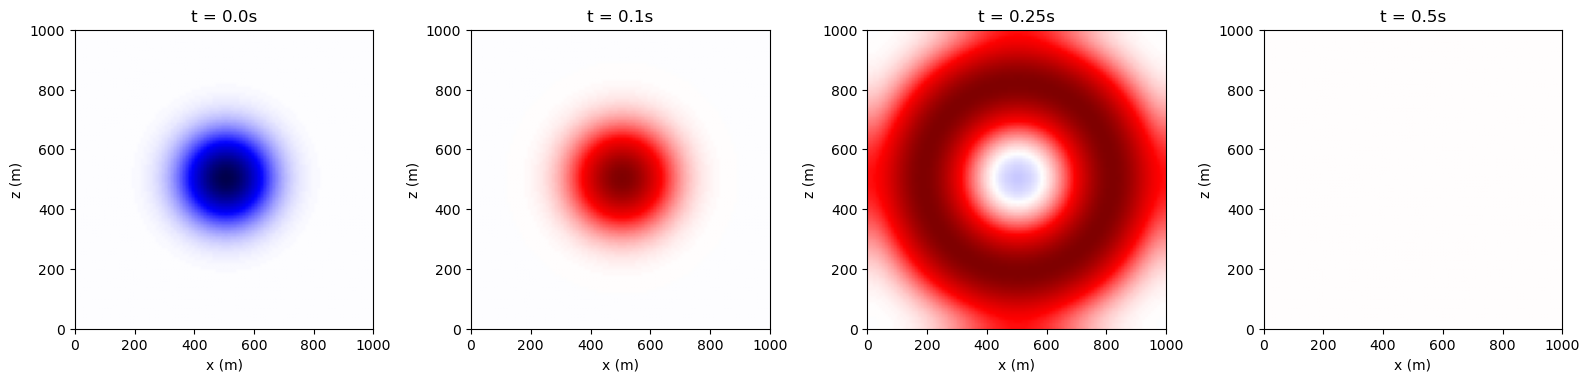

In [241]:
import numpy as np
import matplotlib.pyplot as plt

# Match PINN exactly
nx, nz = 100, 100
dx = dz = 10.0          # 100 points × 10m = 1000m domain
v_fd = 2000.0
f0_fd = 5.0
t0_fd = 1.0 / (np.pi * f0_fd)
t_max_fd = 0.5
dt = 0.4 * dx / v_fd    # CFL condition
nt = int(t_max_fd / dt)

x = np.arange(nx) * dx
z = np.arange(nz) * dz

# Source location
ix_src = nx // 2
iz_src = nz // 2

# Wavefield arrays
u     = np.zeros((nz, nx))
u_old = np.zeros((nz, nx))
u_new = np.zeros((nz, nx))

# Spatial Gaussian for source
sigma_fd = 100.0
X, Z = np.meshgrid(x, z)
gauss = np.exp(-((X - 500)**2 + (Z - 500)**2) / (2*sigma_fd**2))

# Store snapshots at matching times
snap_times = [0.0, 0.1, 0.25, 0.5]
snaps = {}

for it in range(nt):
    t = it * dt

    # FD stencil: u_new = 2u - u_old + (v*dt/dx)^2 * laplacian(u)
    lap = (np.roll(u,1,axis=1) + np.roll(u,-1,axis=1) +
           np.roll(u,1,axis=0) + np.roll(u,-1,axis=0) - 4*u) / dx**2

    src = (1 - 2*(np.pi*f0_fd*(t - t0_fd))**2) * np.exp(-(np.pi*f0_fd*(t-t0_fd))**2)
    
    u_new = 2*u - u_old + (v_fd*dt)**2 * (lap + src * gauss / dx**2)
    u_old, u = u.copy(), u_new.copy()

    for ts in snap_times:
        if abs(t - ts) < dt/2 and ts not in snaps:
            snaps[ts] = u.copy()

# Plot
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, ts in zip(axes, snap_times):
    u_plot = snaps.get(ts, np.zeros((nz,nx)))
    vmax = np.abs(u_plot).max() or 1
    ax.imshow(u_plot, origin='lower', extent=[0,1000,0,1000],
              cmap='seismic', vmin=-vmax, vmax=vmax)
    ax.set_title(f't = {ts}s')
    ax.set_xlabel('x (m)'); ax.set_ylabel('z (m)')
plt.tight_layout()
plt.show()

In [242]:
# Get PINN predictions at same time snapshots
epsilon = {}
for ts in snap_times:
    if abs(t - ts) < dt and ts not in snaps:
        snaps[ts] = u.copy()
    
    # PINN prediction on same grid
    X_flat = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
    Z_flat = torch.tensor(Z.flatten(), dtype=torch.float32).unsqueeze(1)
    T_flat = torch.full_like(X_flat, ts)
    
    with torch.no_grad():
        u_pinn = model(X_flat, Z_flat, T_flat).numpy().reshape(nz, nx)
    
    # Relative L2 error
    num = np.linalg.norm(u_pinn - u_fd)
    den = np.linalg.norm(u_fd)
    epsilon[ts] = num / den if den > 1e-10 else float('nan')
    print(f"t={ts}s: ε = {epsilon[ts]:.4f}")

t=0.0s: ε = 0.9990
t=0.1s: ε = 0.9985
t=0.25s: ε = 1.0048
t=0.5s: ε = 0.9981
